SPAM DETECTION USING NAIVE BAYES 

## Domain Analysis:
The dataset contains SMS messages labeled as Spam or Ham (Not Spam).It is used to train a machine learning model that can automatically,classify incoming messages.

In [ ]:
# Import all the libraries 
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

Load the Dataset

In [3]:
data = pd.read_csv(r"C:\Users\Lenovo\Downloads\spam (1).csv")

## Text Preprocessing
The following NLP techniques were applied:
- Lowercasing
- Removing punctuation
- Tokenization
- Stopword removal
- Stemming

Import NLTK

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Basic Checks

In [4]:
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
data.columns = ['label','message']

In [6]:
data['label_num'] = data['label'].map({'ham':0,'spam':1})

In [16]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    # Convert the text to lowercase.
    text = text.lower()
    # Remove numbers and punctuations
    text = re.sub('[a^zA-Z]','',text)
    # Tokenization
    words = text.split()
    # Remove stopwords and apply stemming
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)
data['processed_message'] = data['message'].apply(preprocess_text)
data.head()

,label,message,label_num,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,"go jurong point, cry.. vilbl bugi n gret world..."
1,ham,Ok lar... Joking wif u oni...,0,ok lr... joke wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entri 2 wkli comp win f cup finl tkt 21st...
3,ham,U dun say so early hor... U c already then say...,0,u dun sy erli hor... u c lredi sy...
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,"nh think goe usf, live round though"


Exploratory Data Analysis(EDA)

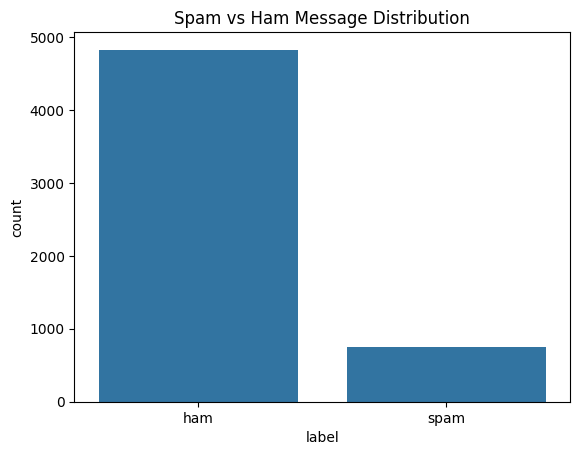

In [ ]:
# Class Distribution of Ham and Spam
sns.countplot(x='label', data=data)
plt.title("Spam vs Ham Message Distribution")
plt.show()

In [34]:
data['message_length'] = data['message'].apply(len)
data.head()

,label,message,label_num,processed_message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,"go jurong point, cry.. vilbl bugi n gret world...",111
1,ham,Ok lar... Joking wif u oni...,0,ok lr... joke wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entri 2 wkli comp win f cup finl tkt 21st...,155
3,ham,U dun say so early hor... U c already then say...,0,u dun sy erli hor... u c lredi sy...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,"nh think goe usf, live round though",61


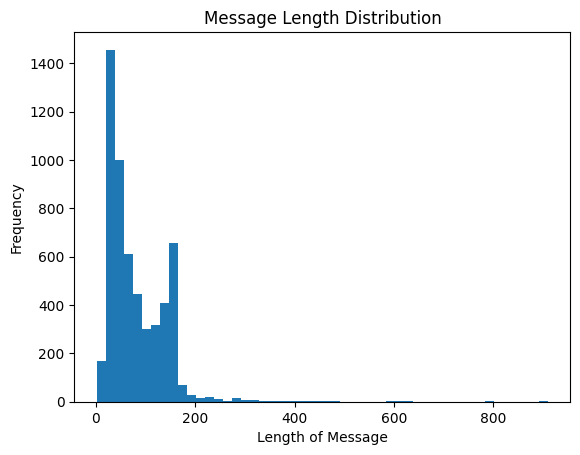

In [35]:
plt.hist(data['message_length'], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Length of Message")
plt.ylabel("Frequency")
plt.show()

Insights:Spam messages tend to have longer text compared to ham messages because they usually include promotional content, offers, or links. Ham messages are generally shorter and more conversational.

In [ ]:
# data groupping by message length.
data.groupby('label')['message_length'].mean()

label
ham      71.44829
spam    137.98929
Name: message_length, dtype: float64

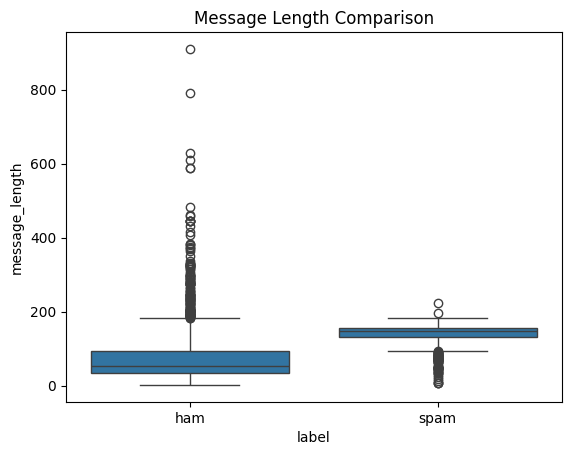

In [ ]:
# Spam Vs Ham Message visualizations
sns.boxplot(x='label', y='message_length', data=data)
plt.title("Message Length Comparison")
plt.show()

Insights:This visualization makes clear about ham and spam the ham is having extreme outliers but not spam the spam is very few.

In [ ]:
# Most common words 
from collections import Counter

all_words = " ".join(data['message']).split()

Counter(all_words).most_common(10)

[('to', 2142),
 ('you', 1626),
 ('I', 1469),
 ('a', 1337),
 ('the', 1204),
 ('and', 858),
 ('in', 798),
 ('is', 787),
 ('i', 748),
 ('u', 696)]

Insights: By this counter we can easly get to know how many commo words are there.

In [17]:
X = data['processed_message']
y = data['label_num']

## Count Vectorizer

The Countvectorizer was used to convert text message into numerical features using the stop words techniques so that the machine learning model can process the data.

In [18]:
cv = CountVectorizer(stop_words='english')
X_vec = cv.fit_transform(X)

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X_vec,y,test_size=0.2,random_state=42)

Model Building

In [29]:
model = MultinomialNB()
model.fit(X_vec,y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:
y_pred = model.predict(X_test)

In [20]:
print("✅ Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 98.12 %

Confusion Matrix:
 [[953  13]
 [  8 141]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.92      0.95      0.93       149

    accuracy                           0.98      1115
   macro avg       0.95      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## Testing With Sample Messages

In [30]:
sample_message = 'Congragulations! You have won a free lottery.Claim your prize now!'
processed = preprocess_text(sample_message)
vector = cv.transform([processed])
prediction = model.predict(vector)[0]
if prediction == 1:
    print('Spam')
else:
    print('Ham(Not Spam)')

Spam


Insights: The model can classify new messages as spam or ham

In [31]:
sample_message = 'Hey, are we meeting tomorrow for the project discussion?'
processed = preprocess_text(sample_message)
vector = cv.transform([processed])
prediction = model.predict(vector)[0]
if prediction == 1:
    print("Spam Message")
else:
    print("Ham (Not Spam) Message")

Ham (Not Spam) Message


Insights: The model can classify new message as spam or ham

## Conclusion

The Naive Bayes model successfully classifies SMS messages as spam or ham using Naive bayes and NLP preprocessing and text vectorzation. This project demonstrates the use of machine learning and natural language processing for automated spam filtering